In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchviz import make_dot

In [2]:
'''
MSP is a fully connected network. It is set up as a simple autoencoder with 1 hidden layer.
'''

class MSP(nn.Module):

    def __init__(self, input_size, hidden_size):
        super(MSP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size, bias = False)  # hidden layer
        self.fc2 = nn.Linear(hidden_size, input_size, bias = False)  # setting up as autoencoder, so output size is same as input size

        torch.nn.init.normal_(self.fc1.weight, mean=0, std=0.1)
        torch.nn.init.normal_(self.fc2.weight, mean=0, std=0.1)

    # normal forward pass
    def forward(self, x):
        x = torch.tanh(self.fc1(x)) # tanh activation function for the hidden layer but can be changed if needed
        x = self.fc2(x) # no non-linearity in the output layer
        return x

    # useful to collect hidden layer activations to look at representations
    def predict_hidden(self, x):
        x = torch.tanh(self.fc1(x)) 
        return x

In [3]:
'''
Define dataset class for the dataloader - this will be used to load the data into the model
'''

class MyDataset(Dataset):
    def __init__(self, data):
        self.data = data
        self.labels = data # note that labels are the same as the data for autoencoder

    def __getitem__(self, index):
        x = self.data[index]
        y = self.labels[index]
        return x, y

    def __len__(self):
        return len(self.data)
    
# set up the dataloader
# data = pd.read_csv('data.csv') # load the data here this should be 1 trial per row and then columns are the features
data = np.random.rand(100, 10) # random data for testing
dataset = MyDataset(data)

In [4]:
'''
Define class to save model output and hidden layer activations
'''

class ModelOutputs:
    def __init__(self):
        self.outputs = np.array([])
        self.hidden = np.array([])
        self.losses = np.array([])

    def save_loss(self, loss):
        self.losses = np.append(self.losses, loss)

    def save_output(self, output):
        self.outputs = np.append(self.outputs, output)

    def save_hidden(self, hidden):
        self.hidden = np.append(self.hidden, hidden)


    def reshape(self, data, shape):
        return data.reshape(shape)

In [5]:
# Set up hyperparameters

input_size = data.shape[1] # number of features in the data
hidden_size = 50 # number of hidden units in the hidden layer - can be changed for your task
learning_rate = 0.01 # learning rate for the optimizer
batch_size = 50 # batch size for training

num_epochs = 300 # number of epochs to train the model
num_runs = 5 # number of times to run the model

In [ ]:
'''
Training Loop
'''

# instantiate ModelOutputs class - use method save_output to save model outputs and save_hidden to save hidden layer activations for later analysis
model_outputs = ModelOutputs()

for run in range(num_runs):
    
    model = MSP(input_size, hidden_size) # set up the model
    criterion = nn.MSELoss() # mean squared error loss function
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) # SGD optimizer

    train_loader = DataLoader(dataset=dataset, batch_size=50, shuffle=True) # set up the dataloader - note batch size is some fraction of the data size

    with torch.no_grad():
        for i, (x, y) in enumerate(train_loader):
            outputs = model(x.float())
            hidden = model.predict_hidden(x.float())
            model_outputs.save_output(outputs)
            model_outputs.save_hidden(hidden)
            

    for epoch in range(num_epochs):
        for i, (x, y) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(x.float())
            loss = criterion(outputs, y.float())
            loss.backward()
            optimizer.step()
            model_outputs.save_output(outputs.detach().numpy())
            hidden = model.predict_hidden(x.float())
            model_outputs.save_hidden(hidden.detach().numpy())
            model_outputs.save_loss(loss.item())

        if epoch % 20 == 0:
            print(f'Run {run + 1}, Epoch {epoch}, Loss {loss.item()}')

Run 1, Epoch 0, Loss 0.29220500588417053
Run 1, Epoch 20, Loss 0.22471007704734802
Run 1, Epoch 40, Loss 0.17955322563648224
Run 1, Epoch 60, Loss 0.13164293766021729
Run 1, Epoch 80, Loss 0.10727406293153763
Run 1, Epoch 100, Loss 0.09189768135547638
Run 1, Epoch 120, Loss 0.07840080559253693
Run 1, Epoch 140, Loss 0.07588762044906616
Run 1, Epoch 160, Loss 0.06694591790437698
Run 1, Epoch 180, Loss 0.06907426565885544
Run 1, Epoch 200, Loss 0.0663931593298912
Run 1, Epoch 220, Loss 0.0689757689833641
Run 1, Epoch 240, Loss 0.06210528686642647
Run 1, Epoch 260, Loss 0.06541400402784348
Run 1, Epoch 280, Loss 0.0646149218082428
Run 2, Epoch 0, Loss 0.329041987657547
Run 2, Epoch 20, Loss 0.24081341922283173
Run 2, Epoch 40, Loss 0.19525963068008423
Run 2, Epoch 60, Loss 0.14446529746055603
Run 2, Epoch 80, Loss 0.12068568170070648
Run 2, Epoch 100, Loss 0.09950730949640274
Run 2, Epoch 120, Loss 0.08958512544631958
Run 2, Epoch 140, Loss 0.07911366969347
Run 2, Epoch 160, Loss 0.073494

In [7]:
# reshape the model outputs and hidden layer activations to be able to analyze them
model_outputs.outputs = model_outputs.reshape(model_outputs.outputs, (num_runs, num_epochs+1, data.shape[0], input_size))
model_outputs.hidden = model_outputs.reshape(model_outputs.hidden, (num_runs, num_epochs+1, data.shape[0], hidden_size))
model_outputs.losses = model_outputs.reshape(model_outputs.losses, (num_runs, num_epochs*2)) # *2 because we save the loss every batch and each epoch is 2 batches

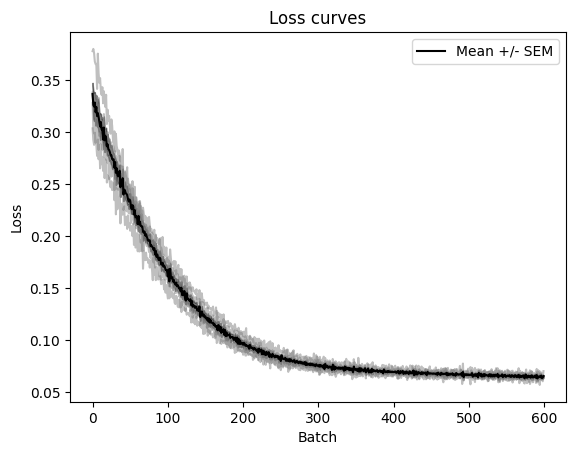

In [8]:
# plot loss curves for each run
for run in range(num_runs):
    plt.plot(model_outputs.losses[run], color='gray', alpha=0.5, label='_nolegend_')

# plot mean loss curve with SEM
plt.plot(np.mean(model_outputs.losses, axis=0), color='black')
plt.fill_between(np.arange(num_epochs*2), np.mean(model_outputs.losses, axis=0) - np.std(model_outputs.losses, axis=0) / np.sqrt(num_runs), np.mean(model_outputs.losses, axis=0) + np.std(model_outputs.losses, axis=0) / np.sqrt(num_runs), alpha=0.5, color='black')

plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Loss curves')
plt.legend(['Mean +/- SEM'])
plt.show()